In [ ]:
#Generate and plot a synthetic imbalanced classification dataset

from collections import Counter
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
#Imbalanced Dataset

X,y = make_classification(n_samples=10000, n_features=2, n_redundant=0, n_clusters_per_class=1, weights=[0.99], random_state=10)
#n_redundant=0 means no extra features,both are informative
#n_clusters_per_class = 1 means that each class will have 1 seperate cluster
#weight is assigned to every class to show its importance,
#here one class is present 99% times whereas,the other class is just 1% times

Counter(y)

Counter({np.int64(0): 9846, np.int64(1): 154})

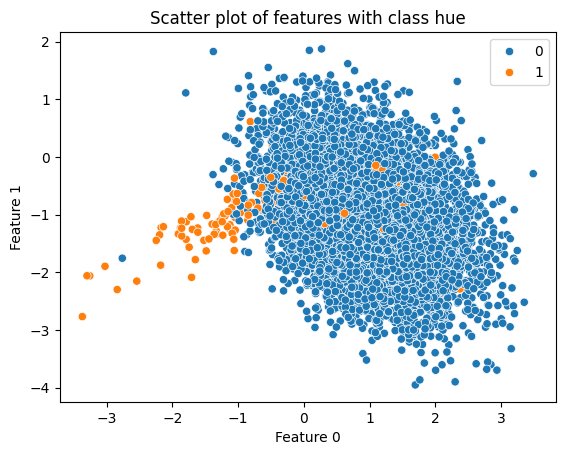

In [ ]:
# Create the DataFrame
df = pd.DataFrame(X, columns=['feature_0', 'feature_1'])
sns.scatterplot(data=df, x='feature_0', y='feature_1', hue=y)   #hue colors the data points based on output feature
plt.title("Scatter plot of features with class hue")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

##HyperParameter Training

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
c_values = [100,10,1.0,0.1,0.01]
max_iters = [100, 200, 500, 1000] # Good to tune this for convergence
class_weight_options = [None, 'balanced']
params = [
    {
        'multi_class': ['ovr'],
        'penalty': ['l1', 'l2'],
        'C': c_values,
        'solver': ['liblinear'],
        'max_iter': max_iters,
        'class_weight': class_weight_options
    },
    {
        'multi_class': ['ovr', 'multinomial'],
        'penalty': ['l2'],
        'C': c_values,
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'max_iter': max_iters,
        'class_weight': class_weight_options
    },
    {
        'multi_class': ['ovr', 'multinomial'],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'C': c_values,
        'solver': ['saga'],
        'l1_ratio': [0.3, 0.5, 0.7],
        'max_iter': max_iters,
        'class_weight': class_weight_options
    }
]

In [ ]:
params

[{'multi_class': ['ovr'],
  'penalty': ['l1', 'l2'],
  'C': [100, 10, 1.0, 0.1, 0.01],
  'solver': ['liblinear'],
  'max_iter': [100, 200, 500, 1000],
  'class_weight': [None, 'balanced']},
 {'multi_class': ['ovr', 'multinomial'],
  'penalty': ['l2'],
  'C': [100, 10, 1.0, 0.1, 0.01],
  'solver': ['lbfgs', 'newton-cg', 'sag'],
  'max_iter': [100, 200, 500, 1000],
  'class_weight': [None, 'balanced']},
 {'multi_class': ['ovr', 'multinomial'],
  'penalty': ['l1', 'l2', 'elasticnet'],
  'C': [100, 10, 1.0, 0.1, 0.01],
  'solver': ['saga'],
  'l1_ratio': [0.3, 0.5, 0.7],
  'max_iter': [100, 200, 500, 1000],
  'class_weight': [None, 'balanced']}]

In [ ]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold
cv = StratifiedKFold()
grid = GridSearchCV(estimator=model, param_grid=params, cv=cv, scoring='accuracy',n_jobs=-1)
grid.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid=[{'C': [100, 10, 1.0, 0.1, 0.01],
                          'class_weight': [None, 'balanced'],
                          'max_iter': [100, 200, 500, 1000],
                          'multi_class': ['ovr'], 'penalty': ['l1', 'l2'],
                          'solver': ['liblinear']},
                         {'C': [100, 10, 1.0, 0.1, 0.01],
                          'class_weight': [None, 'balanced'],
                          'max_iter': [100, 200, 500, 1000],
                          'multi_class': ['ovr', 'multinomial'],
                          'penalty': ['l2'],
                          'solver': ['lbfgs', 'newton-cg', 'sag']},
                         {'C': [100, 10, 1.0, 0.1, 0.01],
                          'class_weight': [None, 'balanced'],
                          'l1_ratio': [0.3, 0.5, 0.7],
                          'max_iter': [100, 200, 500, 1000],
                          'multi_class': ['ovr', 'multinomial'],
                          'penalty': ['l1', 'l2', 'elasticnet'],
                          'solver': ['saga']}],
             scoring='accuracy')

In [ ]:
grid.best_params_

{'C': 100,
 'class_weight': None,
 'max_iter': 100,
 'multi_class': 'ovr',
 'penalty': 'l1',
 'solver': 'liblinear'}

In [ ]:
grid.best_score_

np.float64(0.9870666666666666)

In [ ]:
#Performance metrics

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = grid.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [ ]:
#Confusion matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy)


[[2469    1]
 [  27    3]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2470
           1       0.75      0.10      0.18        30

    accuracy                           0.99      2500
   macro avg       0.87      0.55      0.59      2500
weighted avg       0.99      0.99      0.98      2500

Accuracy: 0.9888
